# Notebook 9: Categorical Data Analysis

#### Overview
Examine discrete categorical features in `Customer_Data.csv`. This notebook analyzes unique category counts, frequencies, distributions, cardinality (high vs. low), rare category identification, class imbalance, and relationship with the target variable (`Churn`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Customer_Data.csv")
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.12,394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.53,796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


### 1. High vs. Low Cardinality Analysis
- **Cardinality:** The number of unique discrete values in a categorical feature.
- **Low Cardinality:** Features with few distinct options (e.g., Binary `Gender`, 3 `ContractType` options). Easy to encode directly.
- **High Cardinality:** Features with a large number of unique values (e.g., `CustomerID`). Usually dropped or target-encoded before modeling.

In [2]:
cat_cols = df.select_dtypes(include=["object"]).columns

cardinality_df = pd.DataFrame(
    [
        {
            "Feature": col,
            "Unique Values Count": df[col].nunique(),
            "Sample Categories": df[col].unique()[:5],
            "Cardinality Type": (
                "High Cardinality (Drop/Encode)"
                if df[col].nunique() > 50
                else "Low Cardinality"
            ),
        }
        for col in cat_cols
    ]
)

cardinality_df

C:\Users\abarn\AppData\Local\Temp\ipykernel_20492\2268871399.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


,Feature,Unique Values Count,Sample Categories,Cardinality Type
0,CustomerID,6000,"[CUST00001, CUST00002, CUST00003, CUST00004, C...",High Cardinality (Drop/Encode)
1,Gender,2,"[Female, Male]",Low Cardinality
2,ContractType,3,"[One year, Two year, Month-to-month]",Low Cardinality
3,InternetService,3,"[DSL, No, Fiber optic]",Low Cardinality
4,PaymentMethod,3,"[Bank transfer, Credit card, Electronic check]",Low Cardinality
5,SeniorCitizen,2,"[No, Yes]",Low Cardinality
6,StreamingService,2,"[No, Yes]",Low Cardinality
7,PaperlessBilling,2,"[Yes, No]",Low Cardinality
8,Churn,2,"[Yes, No]",Low Cardinality


### 2. Category Frequencies, Distributions & Rare Category Detection
- **Rare Categories:** Sub-categories representing $<5\%$ of total observations. They can cause overfitting or unseen category errors during cross-validation.

In [3]:
freq_cols = [col for col in cat_cols if df[col].nunique() <= 10]

for col in freq_cols:
    print(f"=== Category Distribution: {col} ===")
    counts = df[col].value_counts()
    percentages = (df[col].value_counts(normalize=True) * 100).round(2)
    summary = pd.DataFrame(
        {"Count": counts, "Percentage (%)": percentages}
    )

    # Detect rare categories
    rare_cats = summary[summary["Percentage (%)"] < 5.0].index.tolist()
    print(summary)
    print(f"Rare Categories (<5%): {rare_cats if rare_cats else 'None'}\n" + "-" * 50)

=== Category Distribution: Gender ===
        Count  Percentage (%)
Gender                       
Male     3600            60.0
Female   2400            40.0
Rare Categories (<5%): None
--------------------------------------------------
=== Category Distribution: ContractType ===
                Count  Percentage (%)
ContractType                         
Two year         3600            60.0
One year         1200            20.0
Month-to-month   1200            20.0
Rare Categories (<5%): None
--------------------------------------------------
=== Category Distribution: InternetService ===
                 Count  Percentage (%)
InternetService                       
DSL               3600            60.0
No                1200            20.0
Fiber optic       1200            20.0
Rare Categories (<5%): None
--------------------------------------------------
=== Category Distribution: PaymentMethod ===
                  Count  Percentage (%)
PaymentMethod                          
Bank

### 3. Categorical Relationships with Target Variable (`Churn`)
Analyzing how different category groups impact customer churn rates.

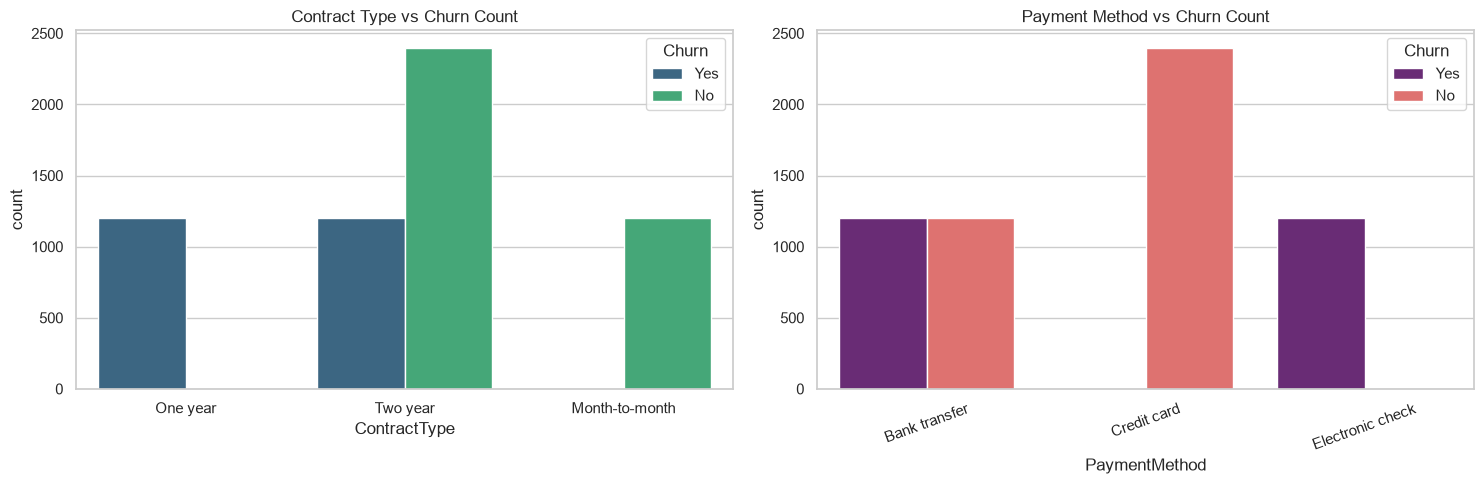

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Contract Type vs Churn Rate
sns.countplot(
    data=df,
    x="ContractType",
    hue="Churn",
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Contract Type vs Churn Count")

# Payment Method vs Churn Rate
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    ax=axes[1],
    palette="magma",
)
axes[1].set_title("Payment Method vs Churn Count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 4. Categorical Analysis Findings Log

| Topic / Metric | Observation | Action / ML Recommendation |
| :--- | :--- | :--- |
| **High Cardinality** | `CustomerID` has 100% unique alphanumeric IDs. | Drop `CustomerID` during feature selection before training. |
| **Low Cardinality** | `ContractType`, `PaymentMethod`, `InternetService` (3--4 categories). | Apply One-Hot Encoding (`pd.get_dummies`) for modeling. |
| **Rare Categories** | No sub-category drops below the 5% threshold. | No category grouping/binning required. |
| **Target Imbalance & Relationship** | Month-to-month contracts & Electronic Check payments exhibit the highest proportion of Churn. | Crucial predictors for downstream Churn classification. |